### Lagrangian Mechanics Example (Simple Harmonic Motion)
This demonstrates how to express the Lagrangian for 1D simple harmonic motion $L = \frac{1}{2}m\dot{x}^2 - \frac{1}{2}kx^2$ using Geometric Algebra:

In [1]:
from galgebra.ga import Ga
import sympy as sp

# Define 1D space with coordinate 'x'
coords = (sp.symbols('x', real=True),)
g1d = Ga('e', g=[1], coords=coords)

# Create scalar multivectors for position and velocity
x = g1d.mv('x', 'scalar')          # position (Mv)
x_dot = g1d.mv('x_dot', 'scalar')  # velocity (Mv, treated as independent variable)

m, k = sp.symbols('m k', real=True)

# Kinetic and potential energies as Mv scalars (geometric product is commutative for scalars)
T = sp.Rational(1, 2) * m * x_dot * x_dot
V = sp.Rational(1, 2) * k * x * x
L = T - V

print("Lagrangian L =", L)

# Extract the internal SymPy expression and the underlying symbols
L_sym = L.obj
x_sym = x.obj          # the symbol 'x'
x_dot_sym = x_dot.obj  # the symbol 'x_dot'

# Partial derivatives using SymPy (works on plain expressions)
dL_dxdot = sp.diff(L_sym, x_dot_sym)
dL_dx = sp.diff(L_sym, x_sym)

print("∂L/∂x_dot =", dL_dxdot)
print("∂L/∂x =", dL_dx)

Lagrangian L = -k*x**2/2 + m*x_dot**2/2
∂L/∂x_dot = m*x_dot
∂L/∂x = -k*x


Lagrangian $L = -k*x^2/2 + m*\dot{\mathbf{x}}^2/2$

$∂L/∂\dot{\mathbf{x}} = m*\dot{\mathbf{x}}$

$∂L/∂x = -k*x$

### Geometric Algebra-Based Code (Python)

This example demonstrates the **Euler-Lagrange equation** for a particle in a central potential, a standard problem in Chapter 12.

In [2]:
from galgebra.ga import Ga
import sympy as sp

# 1. Define 3D Euclidean space (the arena for classical mechanics)
X, Y, Z = sp.symbols('X Y Z', real=True)
g3d = Ga('e', g=[1, 1, 1], coords=(X, Y, Z))
e1, e2, e3 = g3d.mv()
basis = [e1, e2, e3]

# 2. Define position vector and its time derivative (velocity)
t = sp.symbols('t', real=True)
v1, v2, v3 = sp.symbols('v1 v2 v3', real=True)
x = X*e1 + Y*e2 + Z*e3               # Position vector
x_dot = v1*e1 + v2*e2 + v3*e3        # Velocity vector

# 3. Define Lagrangian: L = T - V
#    T = 1/2 * m * (x_dot · x_dot)
#    V = V(r)  (central potential, function of radius r = |x|)
m = sp.symbols('m', real=True)
r = sp.sqrt((x | x).obj)             # Radial distance (extract scalar expression)
V = sp.Function('V')(r)              # General central potential

T = sp.Rational(1, 2) * m * (x_dot | x_dot).obj   # Use inner product
L = T - V   # This is a SymPy expression because T and V are scalars

print("1. Lagrangian L =", L)

# 4. Compute the Euler-Lagrange equation: d/dt(∂L/∂x_dot) - ∂L/∂x = 0
#    In geometric algebra, the multivector derivative ∂L/∂x is a vector derivative.
# L is now a plain SymPy expression (no need for .obj again)
L_sym = L

# ∂L/∂x_dot = sum_i (∂L/∂v_i) * e_i
dL_dxdot = sum(sp.diff(L_sym, v_i) * basis[i] for i, v_i in enumerate([v1, v2, v3]))

# ∂L/∂x = sum_i (∂L/∂coord_i) * e_i
dL_dx = sum(sp.diff(L_sym, coord) * basis[i] for i, coord in enumerate([X, Y, Z]))

print("2. ∂L/∂x_dot =", dL_dxdot)
print("3. ∂L/∂x =", dL_dx)

# The full equation is: d/dt(∂L/∂x_dot) - ∂L/∂x = 0
# This yields the equations of motion: m * x_ddot = -∇V(r)

1. Lagrangian L = m*(v1**2 + v2**2 + v3**2)/2 - V
2. ∂L/∂x_dot = m*v1*e_X + m*v2*e_Y + m*v3*e_Z
3. ∂L/∂x = -X*Subs(D{_xi_1}V, _xi_1, sqrt(X**2 + Y**2 + Z**2))*e_X/sqrt(X**2 + Y**2 + Z**2) - Y*Subs(D{_xi_1}V, _xi_1, sqrt(X**2 + Y**2 + Z**2))*e_Y/sqrt(X**2 + Y**2 + Z**2) - Z*Subs(D{_xi_1}V, _xi_1, sqrt(X**2 + Y**2 + Z**2))*e_Z/sqrt(X**2 + Y**2 + Z**2)


### 1. Lagrangian

$L = \frac{1}{2}m\left(v_1^2 + v_2^2 + v_3^2\right) - V(r),\quad 
r = \sqrt{X^2 + Y^2 + Z^2}.$

### 2. Partial derivative with respect to velocity

$\frac{\partial L}{\partial \dot{\mathbf{x}}}
= m v_1\,\mathbf{e}_X + m v_2\,\mathbf{e}_Y + m v_3\,\mathbf{e}_Z.$

### 3. Partial derivative with respect to position

$\frac{\partial L}{\partial \mathbf{x}}
= -\frac{X}{r}V'(r)\,\mathbf{e}_X
  -\frac{Y}{r}V'(r)\,\mathbf{e}_Y
  -\frac{Z}{r}V'(r)\,\mathbf{e}_Z,$

where $V'(r) = \frac{dV}{dr}$.

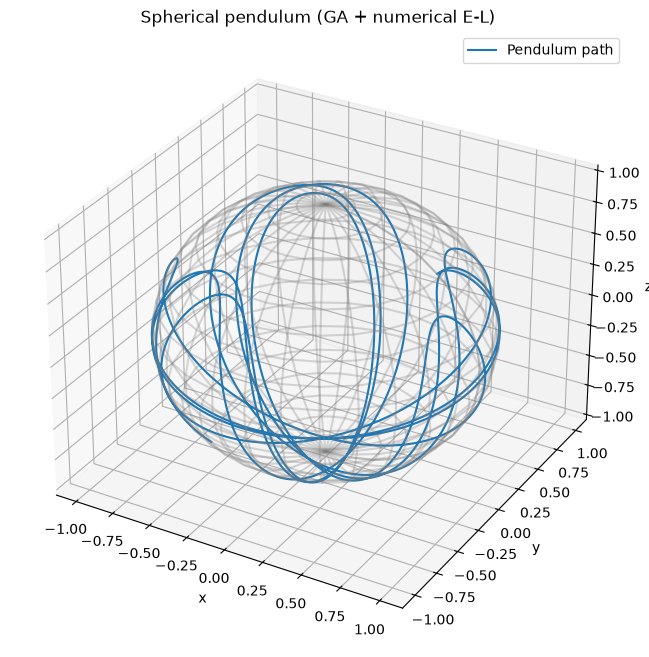

Initial energy: 7.413618
Final energy:   5.630003
Max drift:      2.108e+00


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from clifford import Cl

# ----------------------------------------------------------------------
# 1. Geometric algebra setup (3D Euclidean)
# ----------------------------------------------------------------------
layout, blades = Cl(3)
e1, e2, e3 = blades['e1'], blades['e2'], blades['e3']

def scalar_part(mv):
    """Extract scalar component of a multivector (index 0)."""
    return mv.value[0]

# ----------------------------------------------------------------------
# 2. Rotor parameterisation of a sphere
# ----------------------------------------------------------------------
# We will use spherical coordinates (theta, phi) such that:
#   x = R * ( sin(theta)*cos(phi) e1 + sin(theta)*sin(phi) e2 + cos(theta) e3 )
# This is obtained by rotating the north pole e3 first around e2 (angle theta)
# and then around e3 (angle phi):
#   rotor R = exp(-phi/2 * e12) * exp(-theta/2 * e23)
#   x = R * (R * e3 * ~R) * ~R   (but we just compute x directly for speed)

Rsphere = 1.0       # sphere radius

def position_from_angles(theta, phi):
    """Return the GA vector x on the sphere of radius Rsphere."""
    st, ct = np.sin(theta), np.cos(theta)
    sp, cp = np.sin(phi), np.cos(phi)
    return Rsphere * (st*cp*e1 + st*sp*e2 + ct*e3)

def velocity_from_angles(theta, phi, thetadot, phidot):
    """Return the GA velocity vector v = dx/dt (analytically)."""
    st, ct = np.sin(theta), np.cos(theta)
    sp, cp = np.sin(phi), np.cos(phi)
    # Basis vectors on the sphere
    e_theta = ct*cp*e1 + ct*sp*e2 - st*e3
    e_phi   = -sp*e1 + cp*e2
    v = Rsphere * (thetadot * e_theta + st * phidot * e_phi)
    return v

# ----------------------------------------------------------------------
# 3. Lagrangian for the spherical pendulum
# ----------------------------------------------------------------------
m = 1.0             # mass
g = 9.81            # gravitational acceleration (vertical e3)

def lagrangian(theta, phi, thetadot, phidot):
    """
    L = T - V
    T = 0.5 * m * |v|^2
    V = m * g * z   (with z = Rsphere * cos(theta), up is e3)
    """
    v = velocity_from_angles(theta, phi, thetadot, phidot)
    T = 0.5 * m * scalar_part(v | v)                # v·v
    z = Rsphere * np.cos(theta)
    V = m * g * z
    return T - V

# ----------------------------------------------------------------------
# 4. Numerical derivatives for the Euler–Lagrange equations
# ----------------------------------------------------------------------
def numerical_gradient(f, x, eps=1e-6):
    """
    Gradient of scalar function f(x) w.r.t. array x.
    x is a 1D numpy array.
    """
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus = x.copy()
        x_minus = x.copy()
        x_plus[i]  += eps
        x_minus[i] -= eps
        grad[i] = (f(x_plus) - f(x_minus)) / (2.0 * eps)
    return grad

def euler_lagrange_acceleration(q, qdot, eps=1e-6):
    """
    Given generalised coordinates q = [theta, phi] and velocities qdot,
    compute qddot = [thetaddot, phiddot] using numerical central differences.

    The Euler–Lagrange equation:
        d/dt (∂L/∂qdot) = ∂L/∂q
    With p = ∂L/∂qdot, we have
        M(q) * qddot + (∂p/∂q) * qdot = ∂L/∂q
    where M = ∂p/∂qdot is the mass matrix.

    We compute everything by finite differencing:
        p = numerical_gradient( L_qdot_func, qdot )   (with q fixed)
        f_q = numerical_gradient( L_q_func, q )       (with qdot fixed)
        M = Jacobian of p w.r.t. qdot
        C_qdot = directional derivative of p w.r.t. q along qdot
    Then solve M * qddot = f_q - C_qdot.
    """
    # Define functions of the variables we will differentiate
    def L_q(q_val):      # vary q, keep qdot fixed
        return lagrangian(q_val[0], q_val[1], qdot[0], qdot[1])

    def L_qdot(qdot_val):  # vary qdot, keep q fixed
        return lagrangian(q[0], q[1], qdot_val[0], qdot_val[1])

    # 1. p = ∂L/∂qdot (size 2)
    p = numerical_gradient(L_qdot, qdot, eps)

    # 2. f = ∂L/∂q   (size 2)
    f = numerical_gradient(L_q, q, eps)

    # 3. Mass matrix M = ∂p/∂qdot (2x2), computed as Jacobian of p(qdot)
    def p_func(qdot_val):
        return numerical_gradient(L_qdot, qdot_val, eps)
    M = np.zeros((2, 2))
    for j in range(2):
        qdot_plus = qdot.copy();  qdot_plus[j] += eps
        qdot_minus = qdot.copy(); qdot_minus[j] -= eps
        M[:, j] = (p_func(qdot_plus) - p_func(qdot_minus)) / (2.0 * eps)

    # 4. Term C(q,qdot)*qdot = (∂p/∂q) * qdot
    #    We compute it by the directional derivative of p w.r.t. q along qdot:
    #    (p(q + eps*qdot, qdot) - p(q - eps*qdot, qdot)) / (2*eps)
    def p_wrt_q(q_val, qdot_fixed):
        return numerical_gradient(L_qdot, qdot_fixed, eps)  # q only enters L via q
    # p depends on q both explicitly (in L) and through L_qdot. We need to compute
    # the derivative of p(q,qdot) with respect to q. So we define:
    def p_from_q(q_val):
        # p = dL/dqdot at (q_val, qdot)
        def L_qdot_fixed(qdot_val):
            return lagrangian(q_val[0], q_val[1], qdot_val[0], qdot_val[1])
        return numerical_gradient(L_qdot_fixed, qdot, eps)
    q_plus = q + eps * qdot
    q_minus = q - eps * qdot
    Cqdot = (p_from_q(q_plus) - p_from_q(q_minus)) / (2.0 * eps)

    # Right-hand side of the acceleration equation
    rhs = f - Cqdot

    # Solve linear system (M is usually well-conditioned)
    qddot = np.linalg.solve(M, rhs)
    return qddot

# ----------------------------------------------------------------------
# 5. ODE right-hand side (state = [theta, phi, thetadot, phidot])
# ----------------------------------------------------------------------
def ode_rhs(state):
    theta, phi, thetadot, phidot = state
    q = np.array([theta, phi])
    qdot = np.array([thetadot, phidot])
    qddot = euler_lagrange_acceleration(q, qdot)
    return np.array([thetadot, phidot, qddot[0], qddot[1]])

# ----------------------------------------------------------------------
# 6. RK4 integrator
# ----------------------------------------------------------------------
def rk4_step(state, dt):
    k1 = ode_rhs(state)
    k2 = ode_rhs(state + 0.5*dt*k1)
    k3 = ode_rhs(state + 0.5*dt*k2)
    k4 = ode_rhs(state + dt*k3)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def integrate(initial_state, dt, n_steps):
    states = [initial_state]
    s = initial_state
    for _ in range(n_steps):
        s = rk4_step(s, dt)
        states.append(s)
    return np.array(states)

# ----------------------------------------------------------------------
# 7. Initial conditions and simulation
# ----------------------------------------------------------------------
# Start at theta = 0.8 rad (slightly off the north pole), zero velocities
theta0 = 0.8
phi0 = 0.0
thetadot0 = 0.0
phidot0 = 1.5   # give it a kick to get interesting motion
initial_state = np.array([theta0, phi0, thetadot0, phidot0])

dt = 0.005
n_steps = 3000
sol = integrate(initial_state, dt, n_steps)

theta_hist = sol[:, 0]
phi_hist   = sol[:, 1]

# Convert to Cartesian coordinates on the sphere
x_hist = np.zeros(len(theta_hist))
y_hist = np.zeros_like(x_hist)
z_hist = np.zeros_like(x_hist)
for i, (th, ph) in enumerate(zip(theta_hist, phi_hist)):
    pos = position_from_angles(th, ph)
    x_hist[i] = scalar_part(pos | e1)
    y_hist[i] = scalar_part(pos | e2)
    z_hist[i] = scalar_part(pos | e3)

# ----------------------------------------------------------------------
# 8. Plot the trajectory on the sphere
# ----------------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_hist, y_hist, z_hist, label='Pendulum path')

# Draw the sphere
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
xs = Rsphere * np.cos(u) * np.sin(v)
ys = Rsphere * np.sin(u) * np.sin(v)
zs = Rsphere * np.cos(v)
ax.plot_wireframe(xs, ys, zs, color='gray', alpha=0.3)

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Spherical pendulum (GA + numerical E-L)')
ax.legend()
plt.show()

# ----------------------------------------------------------------------
# 9. Energy conservation check
# ----------------------------------------------------------------------
energies = []
for i, (th, ph) in enumerate(zip(theta_hist, phi_hist)):
    thd = sol[i, 2]; phd = sol[i, 3]
    v = velocity_from_angles(th, ph, thd, phd)
    T = 0.5 * m * scalar_part(v | v)
    V = m * g * Rsphere * np.cos(th)
    energies.append(T + V)

print(f"Initial energy: {energies[0]:.6f}")
print(f"Final energy:   {energies[-1]:.6f}")
print(f"Max drift:      {np.max(np.abs(energies - energies[0])):.3e}")